In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import h5py
import scipy

from gabi_decomp import *
from alfven_decomp import *

In [2]:
# BASIC PARAMS
filename = '/home/stsoukalas/shared/data/LAPD_ALfven_2025-02/b37-40.hdf5'

# GETTING DATASETS
f = h5py.File(filename, 'r')
Bvec = f['B vectors/Bvec']
Bmag = f['B amplitudes/Bmag'] # this one is not used in this notebook currently
times = f['B amplitudes/Timesteps']
spatial_coords = f['Spatial grid']

In [3]:
x, y, z = get_LAPD_domain(spatial_coords)
X, Y = np.meshgrid(x, y, indexing='xy')
dx = x[1] - x[0]
dy = y[1] - y[0]

nphi = 256
phi = gen_phi(nphi)

In [4]:
# i made this decomp + plotting a function so i could more easily iterate over z, t, etc.
def mode_decomp(M, z_slice, t, plot=True, low_pass=True, sigma=1.0):


    Bx_3d, By_3d, Bz_3d = gen_3D_Bvec(time_index=t, Bvec=Bvec, x=x, y=y, z=z, M=M, low_pass=True, sigma=sigma)
    Bx_true_slice, By_true_slice, Bz_true_slice = B_true_slice(Bvec, z_slice, t_index=t, low_pass=True, sigma=sigma)
    
    # gabi's decomposition function
    r_vals, Br, Bp, Bz = make_modes_interp(Bx_3d, By_3d, Bz_3d, x,y,z, modes=M)
    
    # gets the cartesian equivalents of polar domain (this is the reconstructed domain)
    X_rec, Y_rec = get_rec_cartesian_domain(r_vals, phi)

    errors = np.zeros((M+1))
    energies = np.zeros((M+1))

    if plot: # my if plot statements were also an afterthought - this could be structured a bit better
        fig, axes = plt.subplots(3,M+2, figsize=(3*(M+2),12))
    
    for m in range(M+1):
        Br_rec, Bp_rec, Bz_rec = reconstruct_modes(Br, Bp, Bz, phi, m)
        
        Bx_rec_slice, By_rec_slice, Bz_rec_slice = cartesian_rec(Br_rec, Bp_rec, Bz_rec, z_slice, phi)

        # interpolate reconstructed domain onto LAPD domain
        Bx_pred = pred_interp(X_rec, Y_rec, X, Y, Bx_rec_slice)
        By_pred = pred_interp(X_rec, Y_rec, X, Y, By_rec_slice)
        Bz_pred = pred_interp(X_rec, Y_rec, X, Y, Bz_rec_slice)

        errors[m] = norm_L2_error(Bx_true_slice, By_true_slice, Bz_true_slice, Bx_pred, By_pred, Bz_pred)
 
        energies[m] = energy(Bx_pred, By_pred, Bz_pred, dx, dy)


        Bx_masked, Bx_norm = get_color_norm(Bx_true_slice, Bx_pred)
        By_masked, By_norm = get_color_norm(By_true_slice, By_pred)
        Bz_masked, Bz_norm = get_color_norm(Bz_true_slice, Bz_pred)
        
        if plot:
            pcm = axes[0,m].pcolormesh(X, Y, Bx_pred, norm=Bx_norm, cmap='RdBu_r')
            pcm = axes[1,m].pcolormesh(X, Y, By_pred, norm=By_norm, cmap='RdBu_r')
            pcm = axes[2,m].pcolormesh(X, Y, Bz_pred, norm=Bz_norm, cmap='RdBu_r')

    if plot:
        # GROUND TRUTH PCM COLUMN
        pcm_Bx_true = axes[0,M+1].pcolormesh(X, Y, Bx_masked, norm=Bx_norm, cmap='RdBu_r')
        pcm_By_true = axes[1,M+1].pcolormesh(X, Y, By_masked, norm=By_norm, cmap='RdBu_r')
        pcm_Bz_true = axes[2,M+1].pcolormesh(X, Y, Bz_masked, norm=Bz_norm, cmap='RdBu_r')


        # SETTING LABELS
        for i, row in enumerate(axes):
            for j, col in enumerate(row):
                axes[i, j].set_aspect('equal')
                if i == 0:
                    title = f'Mode {j}' if j != M+1 else 'Ground Truth'
                    axes[i, j].set_title(title, fontsize=14)

        axes[0,0].set_ylabel(r'$B_x$', fontsize=14)
        axes[1,0].set_ylabel(r'$B_y$', fontsize=14)
        axes[2,0].set_ylabel(r'$B_z$', fontsize=14)
        fig.tight_layout()

        fig.colorbar(pcm_Bx_true, ax=axes[0,:], orientation='vertical', fraction=0.025, pad=0.04, shrink=0.7, label='Field Magnitude (Global Norm)')
        fig.colorbar(pcm_By_true, ax=axes[1,:], orientation='vertical', fraction=0.025, pad=0.04, shrink=0.7, label='Field Magnitude (Global Norm)')
        fig.colorbar(pcm_Bz_true, ax=axes[2,:], orientation='vertical', fraction=0.025, pad=0.04, shrink=0.7, label='Field Magnitude (Global Norm)')

        fig.suptitle(f'M={M}, z={z_slice}, t={(times[t]*1e6):.1f}us', fontsize=20)

        plt.savefig(f'mode_decomp_figs/M{M}z{z_slice}t{t}.png', bbox_inches='tight')
    
    
    # calculates energies for MASKED fields. 
    # i didn't use the whole square domain for G.T. because it wouldn't be a fair comparison against the reconstructed domain

    gt_energy = energy(Bx_masked, By_masked, Bz_masked, dx, dy)
    energies_norm = energies/gt_energy # normalizes to ground truth energy
    return errors, energies_norm


(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)


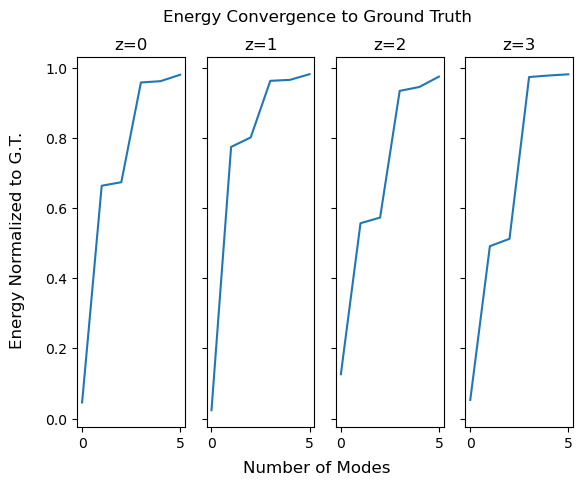

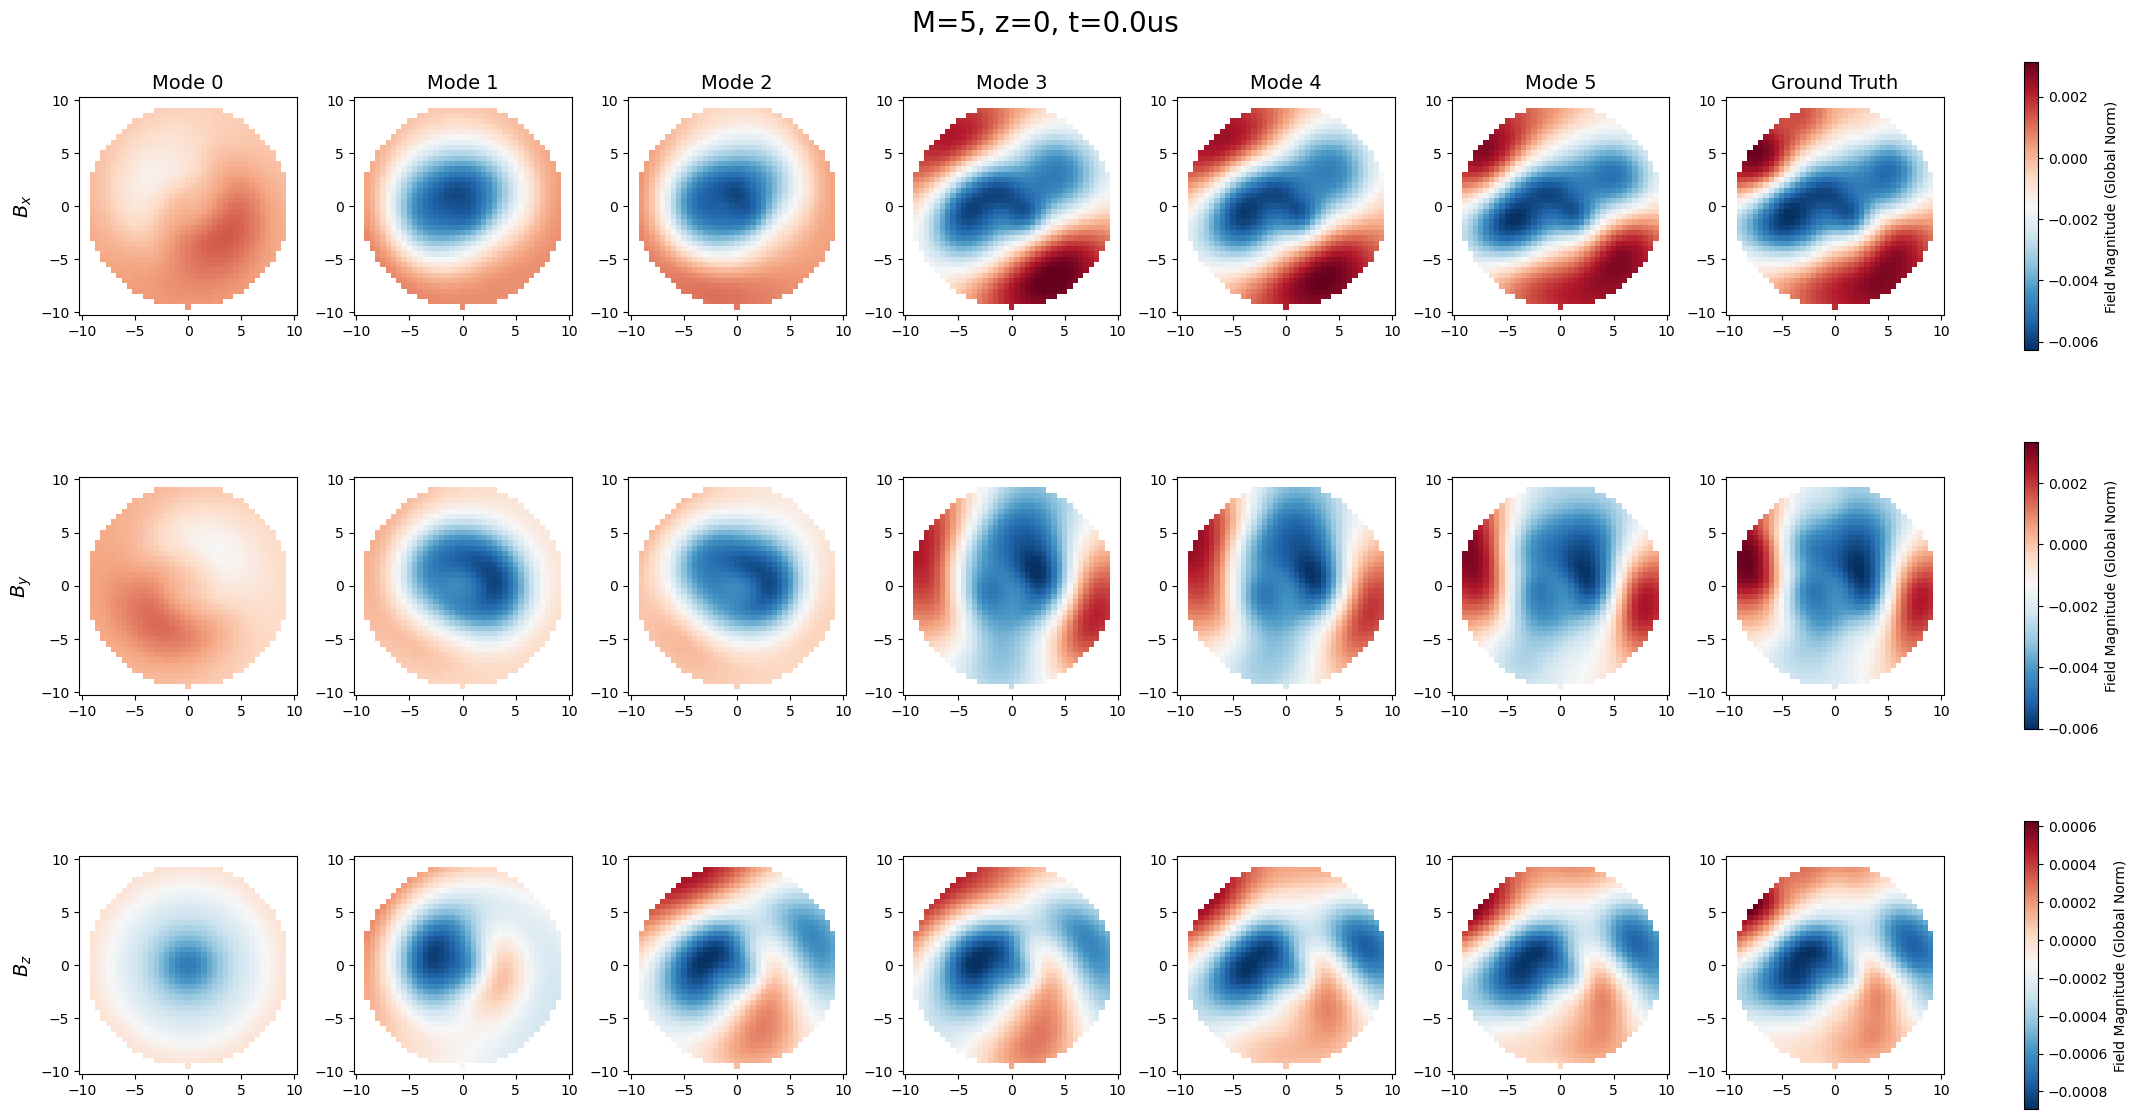

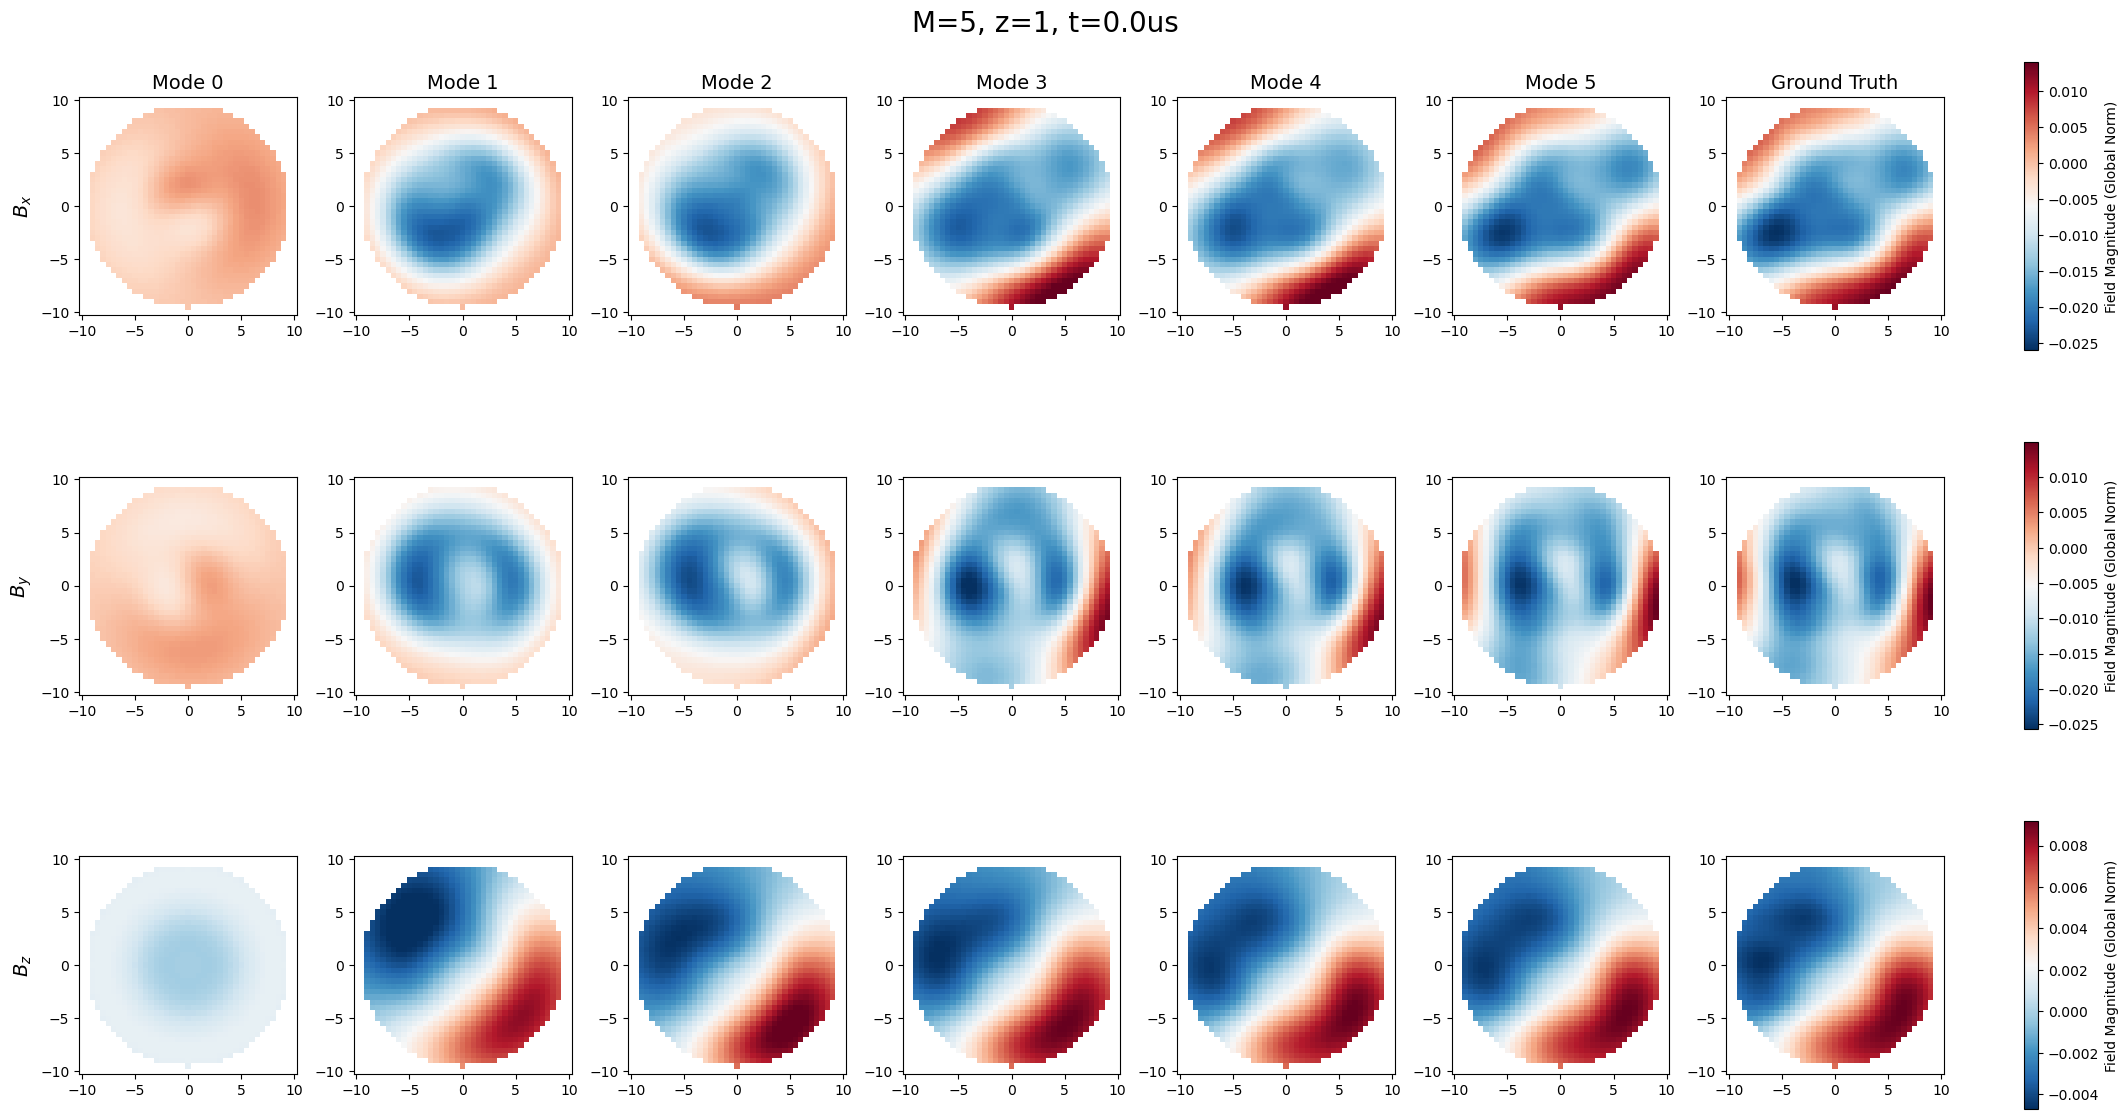

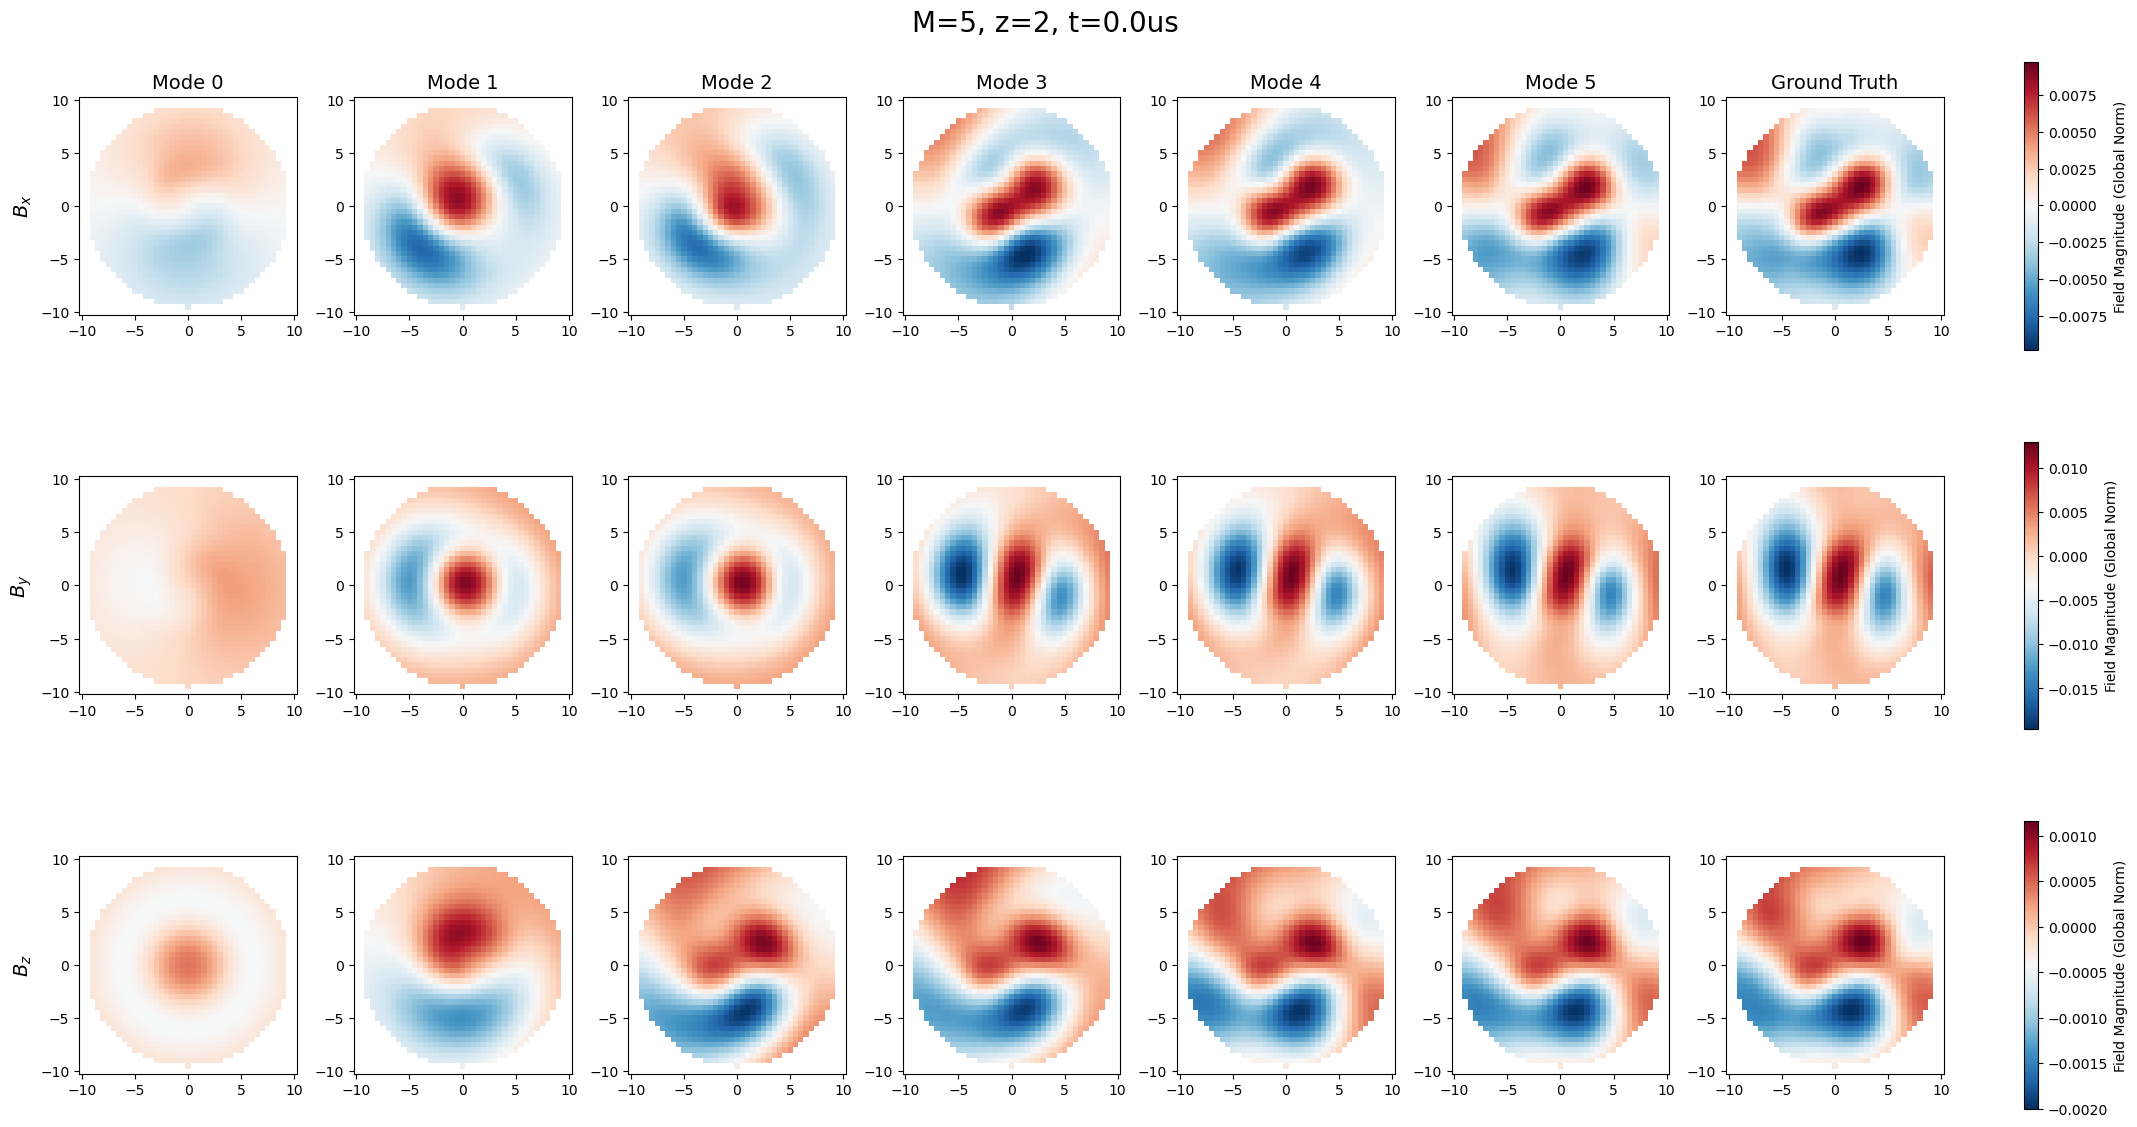

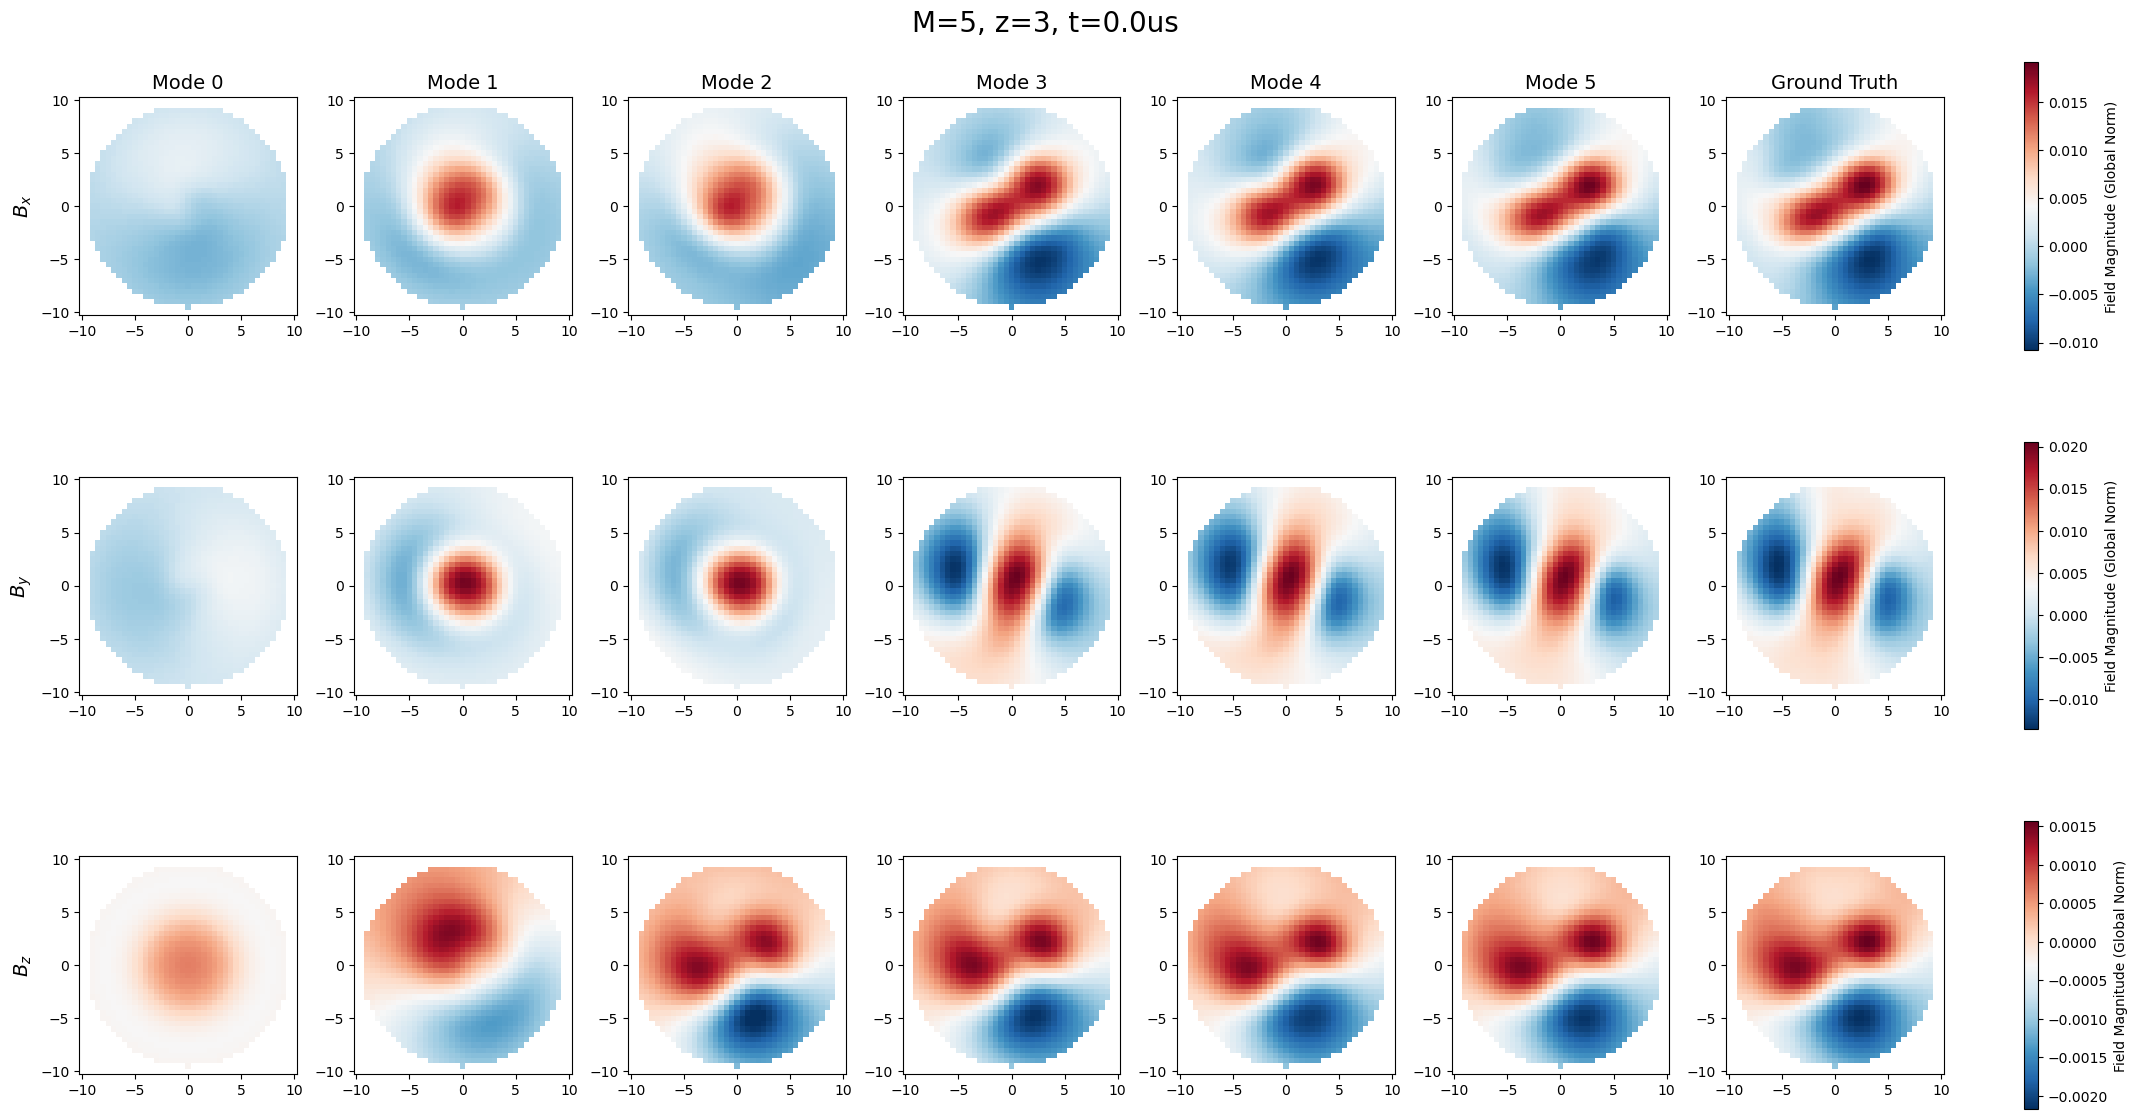

In [7]:
M = 5 # max modes
t = 0 # time index in times array
sigma = 1.5
# iterates over z to produce decomp figures + saves energies and errors
fig, axes = plt.subplots(1, 4, sharey=True)
for z_slice in range(len(z)):
    if z_slice != 0:
        axes[z_slice].tick_params(labelleft=False)  # hide tick labels
    errors, energies = mode_decomp(M, z_slice, t, low_pass=True, sigma=sigma)
    axes[z_slice].plot(energies)
    axes[z_slice].set_title(f'z={z_slice}')
fig.suptitle('Energy Convergence to Ground Truth')
fig.supxlabel('Number of Modes')
fig.supylabel('Energy Normalized to G.T.')
fig.savefig(f'mode_decomp_figs/sigma15M{M}t{t}_energy.png', bbox_inches='tight')
    

(41, 41, 4) (41, 41, 4) (41, 41, 4)


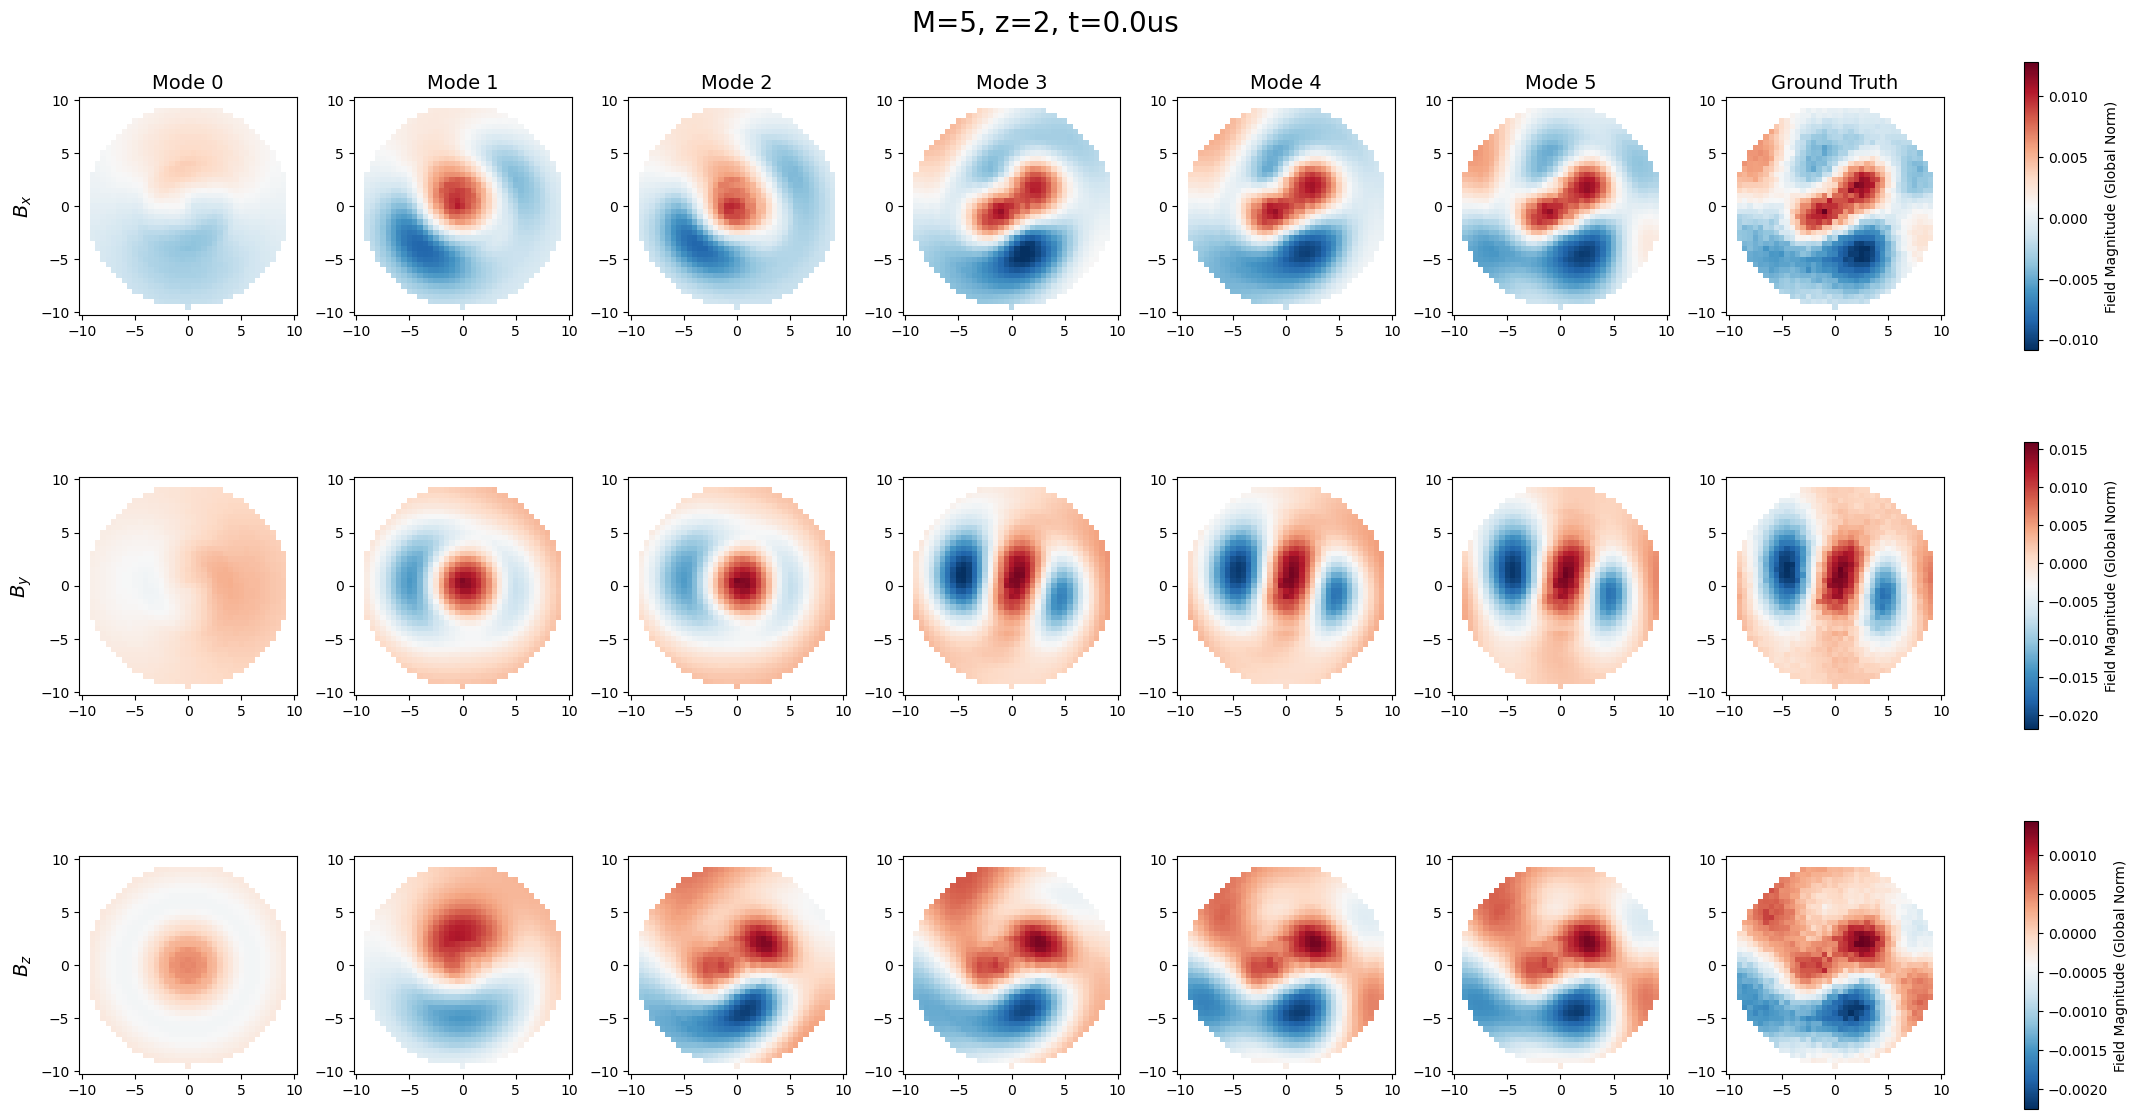

In [5]:
errors, energies = mode_decomp(M=5, z_slice=2, t=0, low_pass=False, sigma=0)

In [ ]:
t=0
M=5
Bx_3d, By_3d, Bz_3d = gen_3D_Bvec(time_index=t, Bvec=Bvec, x=x, y=y, z=z, M=M, low_pass=False, sigma=0)
# Bx_true_slice, By_true_slice, Bz_true_slice = B_true_slice(Bvec, z_slice, t_index=t, low_pass=False)

# gabi's decomposition function
r_vals, Br, Bp, Bz = make_modes_interp(Bx_3d, By_3d, Bz_3d, x,y,z, modes=M)
X_rec, Y_rec = get_rec_cartesian_domain(r_vals, phi)



(41, 41, 4) (41, 41, 4) (41, 41, 4)


(256, 20)

In [19]:
Y_rec.shape

(256, 20)

In [ ]:
select_times = times[::25] # more discretized for testing purposes, can just use times instead of select_times when plotting all timesteps
modes_required = np.zeros_like(select_times)
threshold = 0.95 # % of G.T. energy needed from reconstruction
M = 7 # I set this to 7 to make sure I wasn't missing any higher modes needed for this range
for t_index, time in enumerate(select_times):
    errors, energies_norm = mode_decomp(M, 0, t_index, plot=False)
    mask = energies_norm >= threshold
    idx = np.argmax(mask) if mask.any() else None # first index above threshold if it exists
    modes_required[t_index] = idx

(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41,

([<matplotlib.axis.YTick at 0x7842e99ebe90>,
 [Text(0, 3.0, '3'), Text(0, 4.0, '4'), Text(0, 5.0, '5')])

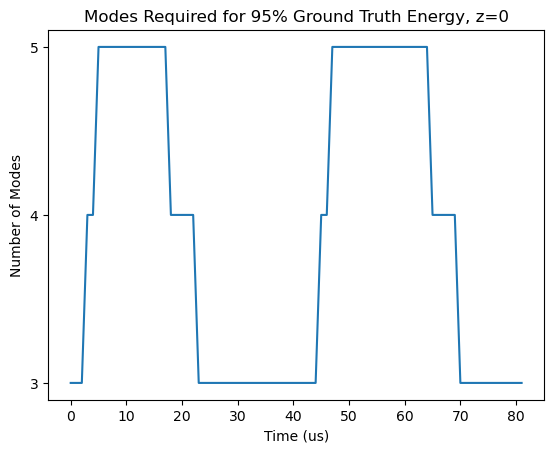

In [7]:
plt.plot(select_times*1e6, modes_required)
# plt.scatter(select_times*1e6, modes_required)
plt.title(f'Modes Required for {(threshold*100):.0f}% Ground Truth Energy, z=0')
plt.xlabel('Time (us)')
plt.ylabel('Number of Modes')
plt.yticks(np.arange(min(modes_required), max(modes_required)+1))

In [8]:
select_times = times[::25] # more discretized for testing purposes, can just use times instead of select_times when plotting all timesteps
modes_required = np.zeros((4, len(select_times)))
threshold = 0.95 # % of G.T. energy needed from reconstruction
M = 7 # I set this to 7 to make sure I wasn't missing any higher modes needed for this range
for z_ind in range(4):
    print(f'z={z_ind}')
    for t_index, time in enumerate(select_times):
        errors, energies_norm = mode_decomp(M, z_ind, t_index, plot=False)
        mask = energies_norm >= threshold
        idx = np.argmax(mask) if mask.any() else None # first index above threshold if it exists
        modes_required[z_ind][t_index] = idx

z=0
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) (41, 41, 4)
(41, 41, 4) (41, 41, 4) 

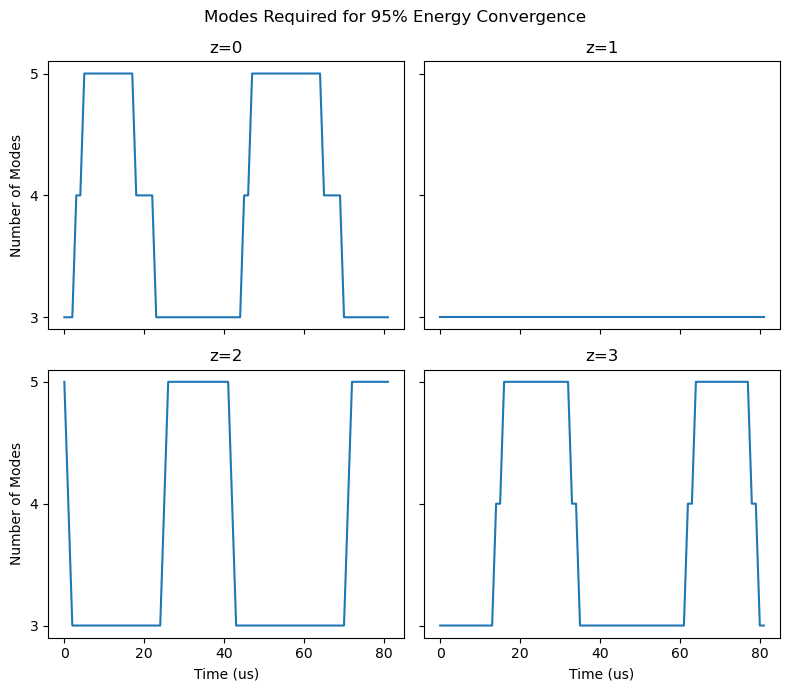

In [25]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8,7))
axes[0,0].plot(select_times*1e6, modes_required[0])
axes[0,0].set_title('z=0')
axes[0,1].plot(select_times*1e6, modes_required[1])
axes[0,1].set_title('z=1')
axes[1,0].plot(select_times*1e6, modes_required[2])
axes[1,0].set_title('z=2')
axes[1,1].plot(select_times*1e6, modes_required[3])
axes[1,1].set_title('z=3')

# axes[0,0].set_xlabel('Time (us)')
# axes[0,1].set_xlabel('Time (us)')
axes[1,0].set_xlabel('Time (us)')
axes[1,1].set_xlabel('Time (us)')

axes[0,0].set_ylabel('Number of Modes')
# axes[0,1].set_ylabel('Number of Modes')
axes[1,0].set_ylabel('Number of Modes')
# axes[1,1].set_ylabel('Number of Modes')
axes[0,0].set_yticks(np.arange(min(modes_required[0]), max(modes_required[0])+1))
axes[0,1].set_yticks(np.arange(min(modes_required[1]), max(modes_required[1])+1))
axes[1,0].set_yticks(np.arange(min(modes_required[2]), max(modes_required[2])+1))
axes[1,1].set_yticks(np.arange(min(modes_required[3]), max(modes_required[3])+1))

fig.suptitle(f'Modes Required for {(threshold*100):.0f}% Energy Convergence')
fig.tight_layout()
fig.savefig('modes_required_95.png', bbox_inches='tight')

# LAPD Bvec Animations

The cell below generates and saves full time animations of each z-slice in Bvec. $B_z$ is contoured and $B_x,B_y$ are represented in streamplots. Took me ~20m to run for full time evolution

z=0 done
z=1 done
z=2 done
z=3 done


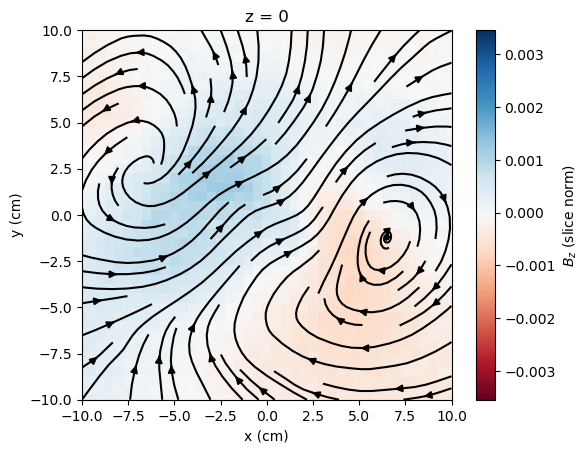

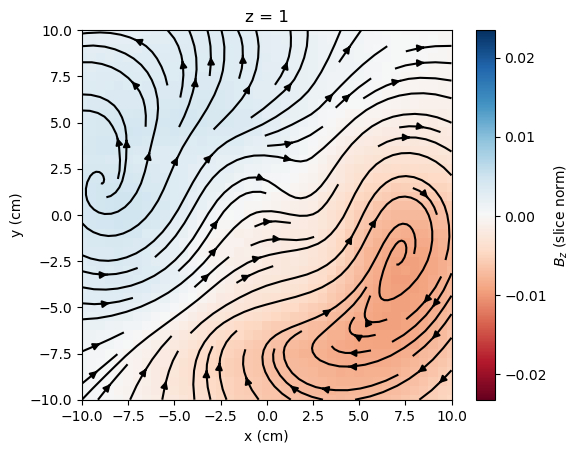

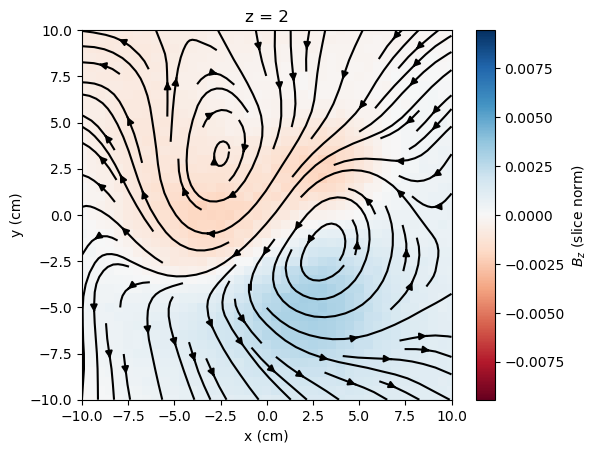

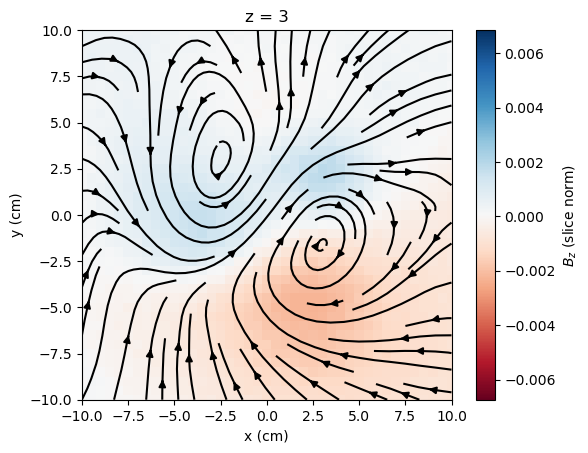

In [ ]:
for i in range(len(z)):
    fig, ax = plt.subplots()

    # normalizes B_z contour to bounds in each z-slice
    all_Bz = [Bvec[t_index][i]['DATA_Z'] for t_index, _ in enumerate(times)]
    Bz_norm_anim = colors.Normalize(vmin=np.min(all_Bz), vmax=np.max(all_Bz))


    Bz0 = Bvec[0][i]["DATA_Z"]
    Bx0 = Bvec[0][i]["DATA_X"]
    By0 = Bvec[0][i]["DATA_Y"]
    
    pcm = ax.pcolormesh(X, Y, Bz0, shading="auto", norm=Bz_norm_anim, cmap='RdBu')
    strm = ax.streamplot(X, Y, Bx0, By0, color="black", density=0.8)
    
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_xlabel('x (cm)')
    ax.set_ylabel('y (cm)')
    ax.set_aspect('equal')
    ax.set_title(f"z = {i}")

    def update(frame):
        global strm
        strm.lines.remove()
        for patch in ax.patches:
            patch.remove()
        
        # new data
        Bx = Bvec[frame][i]["DATA_X"]
        By = Bvec[frame][i]["DATA_Y"]
        Bz = Bvec[frame][i]["DATA_Z"]

        pcm.set_array(Bz.ravel())
        pcm.set_norm(Bz_norm_anim)

        strm = ax.streamplot(X, Y, Bx, By, color="black", density=0.8)

    fig.colorbar(pcm, label=r'$B_z$ (slice norm)', norm=Bz_norm_anim)
    anim = FuncAnimation(fig, update, frames=range(len(times)), interval=50, blit=False)
    anim.save(f'Bvec_z{i}.mp4')

# Misc

this code doesn't work for current iteration of notebook, but gives scaffolding for animating all z-slices of Bvec evolution

In [ ]:
nz=4
all_Bz = np.array([f[z]["DATA_Z"] for f in Bvec for z in range(len(f))], float)
vmin, vmax = np.min(all_Bz), np.max(all_Bz)
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.ravel()

pcms, strms = [], []
for i, ax in enumerate(axes[:nz]):
    Bz0 = Bvec[0][i]["DATA_Z"]
    Bx0 = Bvec[0][i]["DATA_X"]
    By0 = Bvec[0][i]["DATA_Y"]
    pcm = ax.pcolormesh(X, Y, Bz0, shading="auto", vmin=vmin, vmax=vmax, cmap='RdBu')
    strm = ax.streamplot(X, Y, Bx0, By0, color="black", density=0.8)
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_aspect('equal')
    ax.set_title(f"z = {i}")
    pcms.append(pcm)
    strms.append(strm)

fig.colorbar(pcms[0], ax=axes, orientation="vertical",
             fraction=0.03, pad=0.04, label="Bz field (global norm)")

def update(frame):
    for i, ax in enumerate(axes[:nz]):
        # remove old streamlines
        strms[i].lines.remove()
        for patch in ax.patches:
            patch.remove()

        # new data
        Bx = Bvec[frame][i]["DATA_X"]
        By = Bvec[frame][i]["DATA_Y"]
        Bz = Bvec[frame][i]["DATA_Z"]

        pcms[i].set_array(Bz.ravel())  # update colormap
        strms[i] = ax.streamplot(X, Y, Bx, By, color="black", density=0.8)

    fig.suptitle(f"Magnetic field streamlines at t = {(times[frame]*1e6):.1f}us", fontsize=14)

anim = FuncAnimation(fig, update, frames=range(0,100,5), interval=100, blit=False)
plt.show()
anim.save('Bvec_allz_updated.gif')

NameError: name 'np' is not defined